# Quantile Regression Modeling

1. **Model comparison.** In this notebook, I first compared several quantile regression models, including Dummy Regressor, Linear Quantile Regression (LQR), Gradient Boosting Quantile Regression (GBQR), and Quantile Random Forest (QRF). Model performance was evaluated using pinball loss, which is the standard metric for quantile regression. Compared with the dummy baseline, LQR and QRF showed larger pinball loss, while GBQR achieved the best pinball loss. Therefore, GBQR was selected as the main quantile model for this dataset.

2. **Feature reduction.** To improve model stability, a feature-reduction function `preprocessing.py` is used to drop all-zero, constant, and non-feature columns, and optionally drop high correlation and low MI features.

3. **Missing uranium values.** The current GBQR implementation cannot directly handle missing values in "mean_uranium" and "max_uranium". Therefore, missing values in these two columns were manually imputed using the median of each column, and missing-value indicators were also included.

4. **Interpretation of model output.** Because all households within the same FSA share identical predictors, the quantile model assigns the same predicted conditional 90th percentile to all households in that FSA. Therefore, the prediction can be interpreted directly as an FSA-level Q90 estimate.

5. **Training, aggregation, and risk classification.** Five-fold cross-validation was used in this notebook. The model was first trained using household-level data, and the predictions were then grouped by FSA. If the predicted Q90 of an FSA was greater than 200 Bq/m3, that FSA was labeled as high risk.

6. **Hyperparameter tuning.** Hyperparameters were tuned manually under the same grouped five-fold CV scheme used throughout model development.


In [123]:
import pandas as pd
import numpy as np
from pathlib import Path
import geopandas as gpd
import sys
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Add project root to Python path
# ---------------------------------------------------------------------

# project root = two levels above notebooks
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

In [124]:
from src.data.data_loading import (
    load_full_dataset,
    load_full_training_pool,
    load_test_data,
    load_training_data,
    load_validation_data
)

In [125]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_pinball_loss
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from quantile_forest import RandomForestQuantileRegressor
from sklearn.inspection import permutation_importance

In [126]:
# Feature preparation
# Use a basic cleaned feature set
#non_feature_cols = ["FSA", "n_days", "concentration", "is_test", "cv_fold", "provinceterritory", "geometry", "spatial_cluster"]

Reduce features:

In [127]:
from src.features import preprocessing
DROP_HIGH_CORR = True
DROP_LOW_MI = False

train_pool_df = load_full_training_pool().copy()

feature_cols, drop_reasons = preprocessing.build_feature_list(
    train_pool_df,
    drop_high_corr = False,     ### select whether to drop high correlation features
    drop_low_mi = False,        ### select whether to drop low MI features
)

print(f"Number of selected features: {len(feature_cols)}")
for reason, cols in drop_reasons.items():
    if cols:
        print(f"{reason}: {len(cols)}")

Number of selected features: 59
non_feature: 8
all_zero: 8
compositional_reference: 6


Linear QR and Gradient Boosting QR cannot handle NaN values in "mean_uranium" and "max_uranium".

Use median of "mean_uranium" and "max_uranium" in each training set to fill the NaN values.

In [128]:
def prepare_X_y(df):
    df = df.copy()
    df["log_concentration"] = np.log(df["concentration"]) 

    # missing indicators for mean_uranium and max_uranium
    df["mean_uranium_missing"] = df["mean_uranium"].isna().astype(int)
    df["max_uranium_missing"] = df["max_uranium"].isna().astype(int)

    y = df["log_concentration"]
    X = df[feature_cols].copy()
    return X, y

In [129]:
def impute_train_val(X_train, X_val):
    imputer = SimpleImputer(strategy="median")
    
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_val_imp = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )
    return X_train_imp, X_val_imp

#### Dummy Regressor - Baseline Model

In [130]:
all_losses = {0.95: [], 0.9: [], 0.75: [], 0.5: []}

for fold in range(5):
    train_df = load_training_data(cv_fold=fold)
    val_df = load_validation_data(cv_fold=fold)

    X_train, y_train = prepare_X_y(train_df)
    X_val, y_val = prepare_X_y(val_df)

    X_train_imp, X_val_imp = impute_train_val(X_train, X_val)
    
    results = []
    for q in [0.95, 0.9, 0.75, 0.5]:
        model_dummy = DummyRegressor(strategy = "quantile", quantile = q)
        model_dummy.fit(X_train_imp, y_train)
        preds = model_dummy.predict(X_val_imp)
        loss = mean_pinball_loss(y_val, preds, alpha=q)
        results.append((q, loss))
        all_losses[q].append(loss)

    print(f"{fold}-fold: {results}")

all_models_results = []
for q in [0.95, 0.9, 0.75, 0.5]:
    mean_loss = np.mean(all_losses[q])
    std_loss = np.std(all_losses[q])

    all_models_results.append(
        {
            "model": "Dummy",
            "quantile": q,
            "mean_loss": mean_loss,
            "std": std_loss
        }
    )

results_df = pd.DataFrame(all_models_results)
results_df

0-fold: [(0.95, 0.11748196563768785), (0.9, 0.19931993439034998), (0.75, 0.3721192178939211), (0.5, 0.5022030687200296)]
1-fold: [(0.95, 0.12351362433601888), (0.9, 0.2126393257145586), (0.75, 0.4069613603534319), (0.5, 0.5539061259528802)]
2-fold: [(0.95, 0.1239560894333368), (0.9, 0.21027064093685008), (0.75, 0.37821261803394246), (0.5, 0.5086737278731298)]
3-fold: [(0.95, 0.11612840642517798), (0.9, 0.19949865150277168), (0.75, 0.36913352126713916), (0.5, 0.509063144420354)]
4-fold: [(0.95, 0.11934742799284431), (0.9, 0.20525984691655408), (0.75, 0.38779962569939797), (0.5, 0.5244342866572719)]


,model,quantile,mean_loss,std
0,Dummy,0.95,0.120086,0.003153
1,Dummy,0.90,0.205398,0.005440
2,Dummy,0.75,0.382845,0.013643
3,Dummy,0.50,0.519656,0.018619


### Linear Quantile Regression

In [131]:
all_losses = {0.95: [], 0.9: [], 0.75: [], 0.5: []}
coef_store = {0.95: [], 0.9: [], 0.75: [], 0.5: []}

for fold in range(5):
    train_df = load_training_data(cv_fold=fold)
    val_df = load_validation_data(cv_fold=fold)

    X_train, y_train = prepare_X_y(train_df)
    X_val, y_val = prepare_X_y(val_df)

    X_train_imp, X_val_imp = impute_train_val(X_train, X_val)
    
    results = []
    for q in [0.95, 0.9, 0.75, 0.5]:
        model_linearQR = QuantileRegressor(quantile = q, alpha=0)
        model_linearQR.fit(X_train_imp, y_train)
        preds = model_linearQR.predict(X_val_imp)
        loss = mean_pinball_loss(y_val, preds, alpha=q)
        results.append((q, loss))
        all_losses[q].append(loss)

        coef_series = pd.Series(model_linearQR.coef_, index=X_train_imp.columns, name=f"fold_{fold}")
        coef_store[q].append(coef_series)

    print(f"{fold}-fold: {results}")

#all_models_results = []
for q in [0.95, 0.9, 0.75, 0.5]:
    mean_loss = np.mean(all_losses[q])
    std_loss = np.std(all_losses[q])

    all_models_results.append(
        {
            "model": "Linear Quantile Regressor",
            "quantile": q,
            "mean_loss": mean_loss,
            "std": std_loss
        }
    )

results_df = pd.DataFrame(all_models_results)
results_df

0-fold: [(0.95, 0.524430638694996), (0.9, 1.0501789724404025), (0.75, 0.36242061559886807), (0.5, 1.7931096508671527)]
1-fold: [(0.95, 0.18151032888007274), (0.9, 0.2769476593468778), (0.75, 0.4359434635366931), (0.5, 0.5388906165198492)]
2-fold: [(0.95, 0.15861834858966137), (0.9, 0.2286412453269457), (0.75, 0.3825874557657588), (0.5, 0.4799498727608408)]
3-fold: [(0.95, 0.1279465222319356), (0.9, 0.21226785300273548), (0.75, 0.3863170678301426), (0.5, 0.49644423084624606)]
4-fold: [(0.95, 0.1522028615310032), (0.9, 0.2744141488596674), (0.75, 0.4607335520477471), (0.5, 0.5233258961605538)]


,model,quantile,mean_loss,std
0,Dummy,0.95,0.120086,0.003153
1,Dummy,0.90,0.205398,0.005440
2,Dummy,0.75,0.382845,0.013643
3,Dummy,0.50,0.519656,0.018619
4,Linear Quantile Regressor,0.95,0.228942,0.148726
5,Linear Quantile Regressor,0.90,0.408490,0.321836
6,Linear Quantile Regressor,0.75,0.405600,0.036678
7,Linear Quantile Regressor,0.50,0.766344,0.513791


In [132]:
#### Preliminary LQR results show instability in Fold 0
####### - Problem solved after reduced some features.

After reducing high-correlation, high-MI, low variance, and all-zero features, LQR no longer shows instability in Fold 0. 

But at high quantiles (0.90 & 0.95), it performs worse than Dummy model.

In [133]:
def summarize_coefs(coef_store, q):
    coef_df = pd.concat(coef_store[q], axis=1)
    coef_df.columns = [f"fold_{i}" for i in range(coef_df.shape[1])]
    
    coef_summary = pd.DataFrame({
        "mean_coef": coef_df.mean(axis=1),
        "std_coef": coef_df.std(axis=1)
    })
    coef_summary["abs_mean_coef"] = coef_summary["mean_coef"].abs()
    
    return coef_df, coef_summary

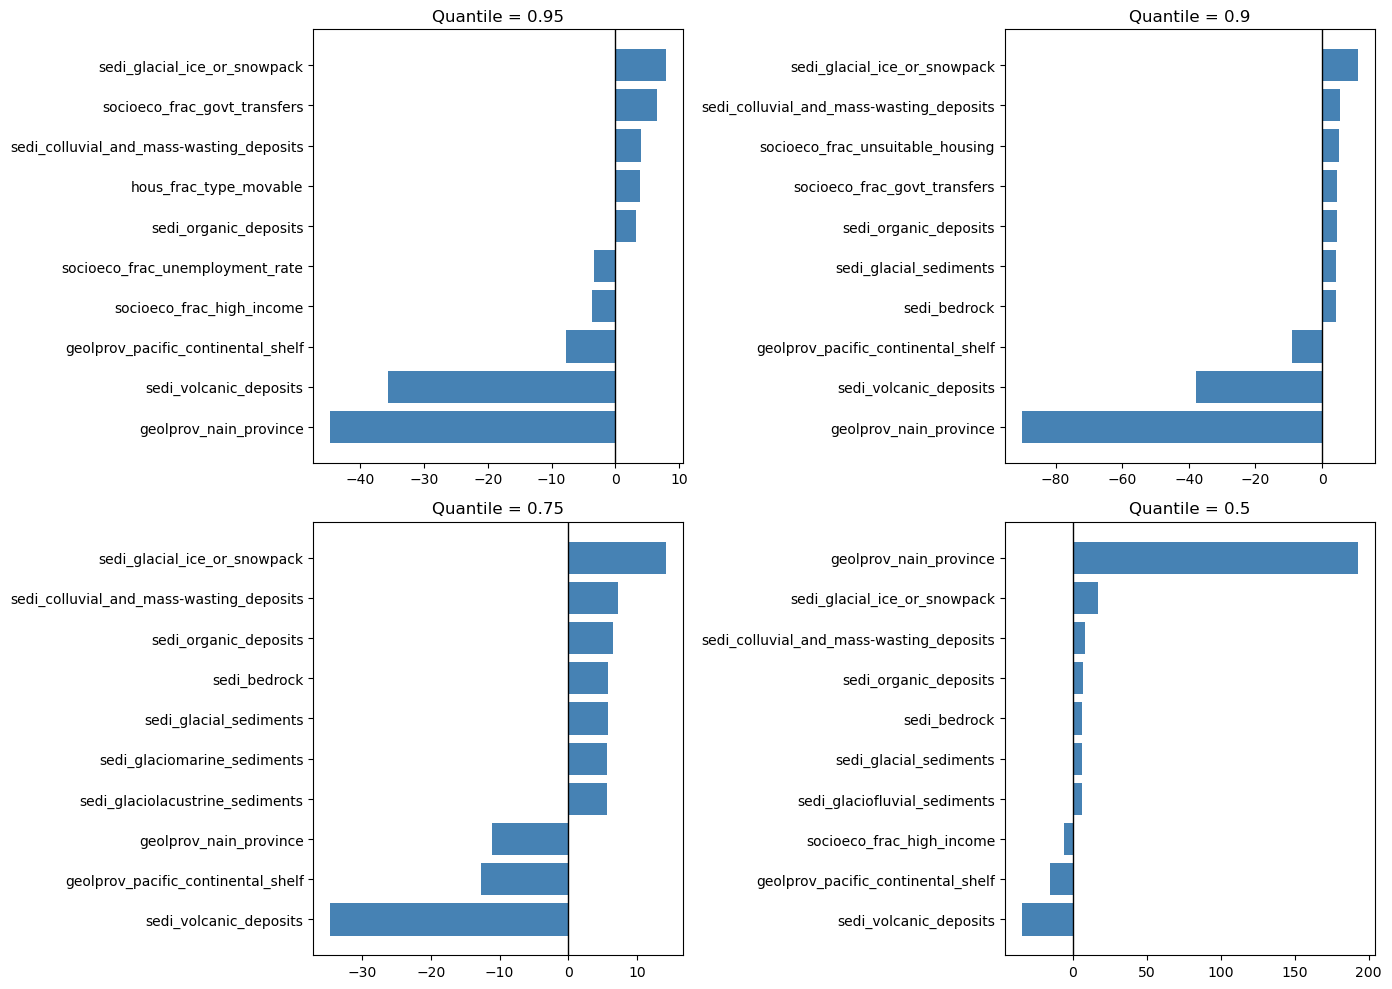

In [134]:
import matplotlib.pyplot as plt

qs = [0.95, 0.9, 0.75, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, q in zip(axes, qs):

    coef_df = pd.concat(coef_store[q], axis=1)

    coef_summary = pd.DataFrame({
        "mean_coef": coef_df.mean(axis=1),
        "abs_coef": coef_df.mean(axis=1).abs()
    })

    plot_df = (
        coef_summary
        .sort_values("abs_coef", ascending=False)
        .head(10)
        .sort_values("mean_coef")
    )

    ax.barh(
        plot_df.index,
        plot_df["mean_coef"],
        color="steelblue"
    )

    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Quantile = {q}")

plt.tight_layout()
plt.show()

### Gradient Boosting Quantile Regression

In [135]:
all_losses = {0.95: [], 0.9: [], 0.75: [], 0.5: []}
gbqr_imp_store = {0.95: [], 0.9: [], 0.75: [], 0.5: []}

for fold in range(5):
    train_df = load_training_data(cv_fold=fold)
    val_df = load_validation_data(cv_fold=fold)

    X_train, y_train = prepare_X_y(train_df)
    X_val, y_val = prepare_X_y(val_df)

    X_train_imp, X_val_imp = impute_train_val(X_train, X_val)
    
    results = []
    for q in [0.95, 0.9, 0.75, 0.5]:
        model_gbqr = GradientBoostingRegressor(
            loss='quantile', alpha=q, n_estimators=200, learning_rate=0.05, max_depth=3, random_state=12345
            )
        model_gbqr.fit(X_train_imp, y_train)
        preds = model_gbqr.predict(X_val_imp)
        loss = mean_pinball_loss(y_val, preds, alpha=q)
        results.append((q, loss))
        all_losses[q].append(loss)

        # Permutation importance
        perm_result = permutation_importance(
            model_gbqr,
            X_val_imp,
            y_val,
            n_repeats=10,
            random_state=12345,
            n_jobs=-1,
            scoring="neg_mean_absolute_error"
        )

        imp_series = pd.Series(
            perm_result.importances_mean,
            index=X_val_imp.columns,
            name=f"fold_{fold}"
        )
        gbqr_imp_store[q].append(imp_series)

    print(f"{fold}-fold: {results}")

#all_models_results = []
for q in [0.95, 0.9, 0.75, 0.5]:
    mean_loss = np.mean(all_losses[q])
    std_loss = np.std(all_losses[q])

    all_models_results.append(
        {
            "model": "Gradient Boosting Quantile Regressor",
            "quantile": q,
            "mean_loss": mean_loss,
            "std": std_loss
        }
    )

results_df = pd.DataFrame(all_models_results)
results_df

0-fold: [(0.95, 0.11118027198547274), (0.9, 0.18776143602402753), (0.75, 0.34450750496575594), (0.5, 0.4331715826380029)]
1-fold: [(0.95, 0.11470642132769736), (0.9, 0.19180144841174795), (0.75, 0.3632114386089805), (0.5, 0.4660625504936057)]
2-fold: [(0.95, 0.12774670285511416), (0.9, 0.2091105660587233), (0.75, 0.3657402182556689), (0.5, 0.4733799699991612)]
3-fold: [(0.95, 0.11299191098400935), (0.9, 0.19479820140101037), (0.75, 0.3616151117769493), (0.5, 0.46313191169758167)]
4-fold: [(0.95, 0.10745679168327153), (0.9, 0.18406723189260352), (0.75, 0.33070363748293774), (0.5, 0.4089071665035646)]


,model,quantile,mean_loss,std
0,Dummy,0.95,0.120086,0.003153
1,Dummy,0.90,0.205398,0.005440
2,Dummy,0.75,0.382845,0.013643
3,Dummy,0.50,0.519656,0.018619
4,Linear Quantile Regressor,0.95,0.228942,0.148726
5,Linear Quantile Regressor,0.90,0.408490,0.321836
6,Linear Quantile Regressor,0.75,0.405600,0.036678
7,Linear Quantile Regressor,0.50,0.766344,0.513791
8,Gradient Boosting Quantile Regressor,0.95,0.114816,0.006898
9,Gradient Boosting Quantile Regressor,0.90,0.193508,0.008604


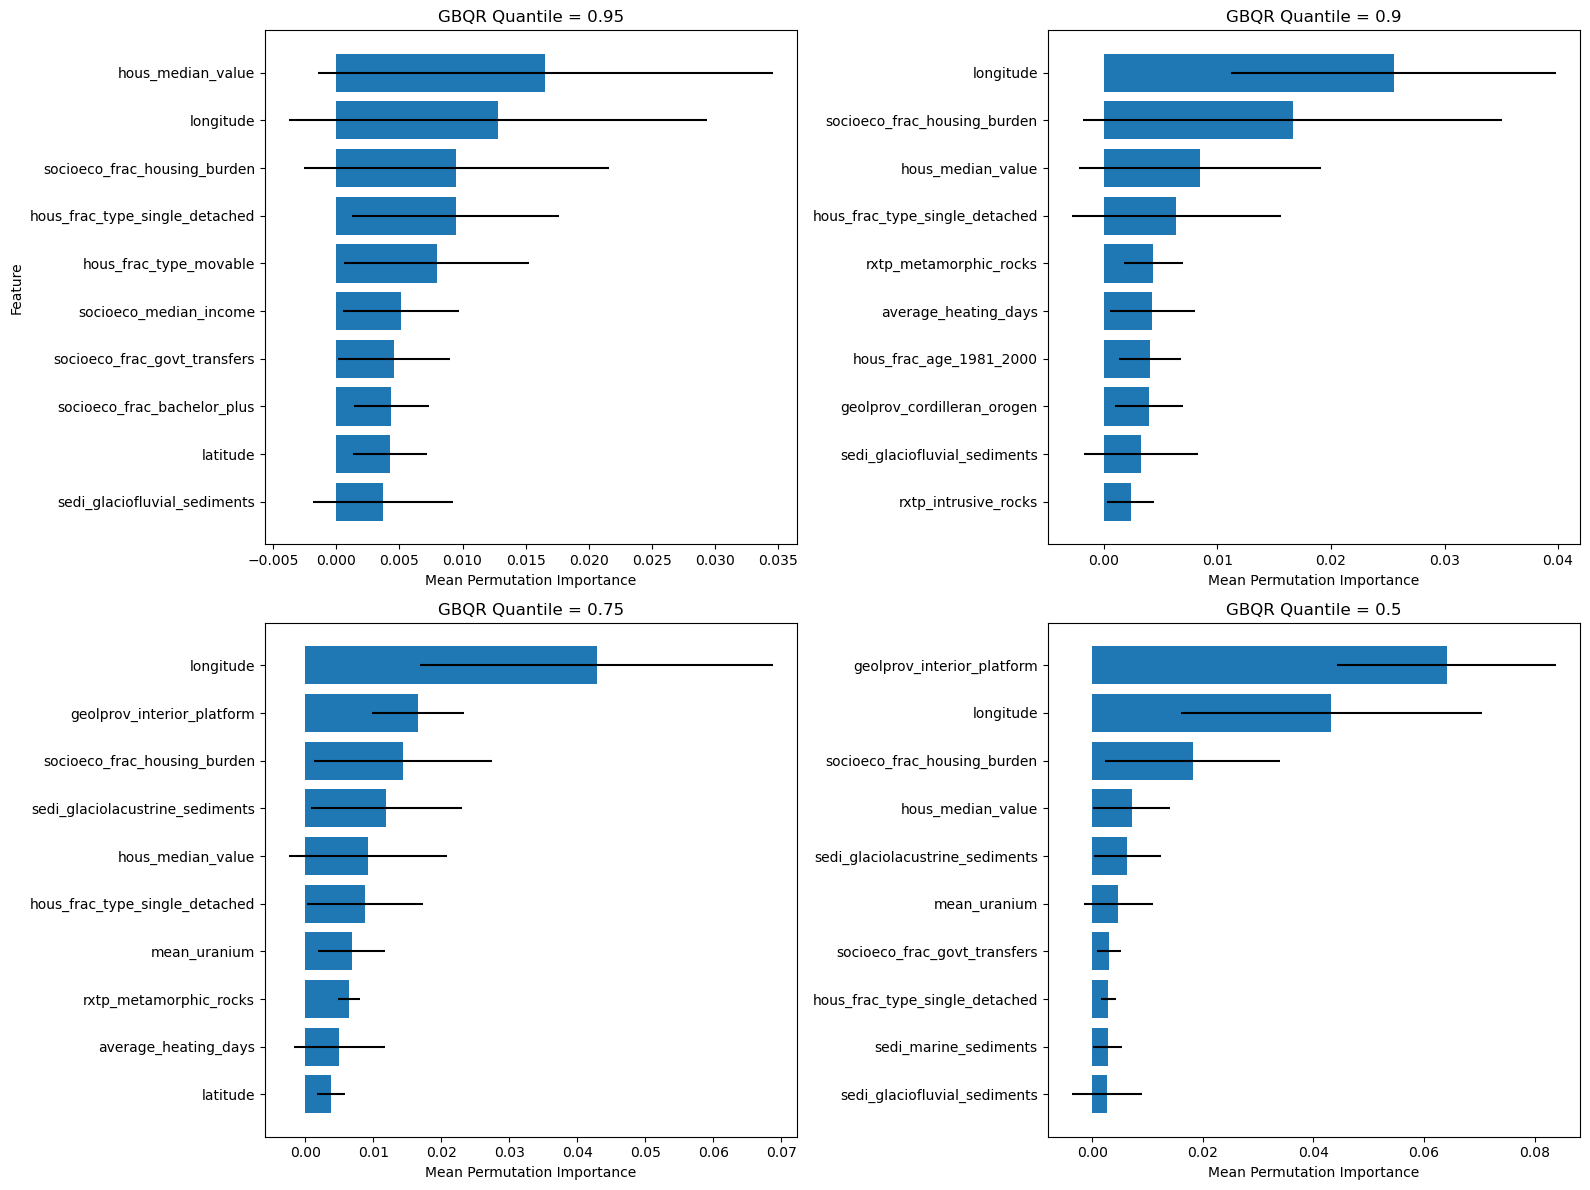

In [136]:
qs = [0.95, 0.9, 0.75, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, q in zip(axes, qs):
    imp_df = pd.concat(gbqr_imp_store[q], axis=1)
    imp_df.columns = [f"fold_{i}" for i in range(imp_df.shape[1])]

    imp_summary = pd.DataFrame({
        "mean_importance": imp_df.mean(axis=1),
        "std_importance": imp_df.std(axis=1)
    })

    plot_df = (
        imp_summary
        .sort_values("mean_importance", ascending=False)
        .head(10)
        .sort_values("mean_importance")
    )

    ax.barh(
        plot_df.index,
        plot_df["mean_importance"],
        xerr=plot_df["std_importance"]
    )
    ax.set_title(f"GBQR Quantile = {q}")
    ax.set_xlabel("Mean Permutation Importance")

axes[0].set_ylabel("Feature")
plt.tight_layout()
plt.show()

### Quantile Regression Forest


In [137]:
all_losses = {0.95: [], 0.9: [], 0.75: [], 0.5: []}

for fold in range(5):
    train_df = load_training_data(cv_fold=fold)
    val_df = load_validation_data(cv_fold=fold)

    X_train, y_train = prepare_X_y(train_df)
    X_val, y_val = prepare_X_y(val_df)

    X_train_imp, X_val_imp = impute_train_val(X_train, X_val)
    
    results = []
    for q in [0.95, 0.9, 0.75, 0.5]:
        model_qrf = RandomForestQuantileRegressor(
            n_estimators=500, max_depth=15, min_samples_leaf=1, random_state=12345, n_jobs=-1
            )
        model_qrf.fit(X_train_imp, y_train)
        preds = model_qrf.predict(X_val_imp)
        loss = mean_pinball_loss(y_val, preds, alpha=q)
        results.append((q, loss))
        all_losses[q].append(loss)

    print(f"{fold}-fold: {results}")

#all_models_results = []
for q in [0.95, 0.9, 0.75, 0.5]:
    mean_loss = np.mean(all_losses[q])
    std_loss = np.std(all_losses[q])

    all_models_results.append(
        {
            "model": "Quantile Forest Regressor",
            "quantile": q,
            "mean_loss": mean_loss,
            "std": std_loss
        }
    )

results_df = pd.DataFrame(all_models_results)
results_df

0-fold: [(0.95, 0.4068905255026358), (0.9, 0.40982758771997857), (0.75, 0.4186387743720067), (0.5, 0.4333240854587203)]
1-fold: [(0.95, 0.4632622140582883), (0.9, 0.4620181218713109), (0.75, 0.4582858453103788), (0.5, 0.452065384375492)]
2-fold: [(0.95, 0.5038546216598387), (0.9, 0.5000123913879289), (0.75, 0.4884857005721995), (0.5, 0.46927454921265066)]
3-fold: [(0.95, 0.4754359741476634), (0.9, 0.4729383629092626), (0.75, 0.4654455291940603), (0.5, 0.45295747300205647)]
4-fold: [(0.95, 0.3491059557705751), (0.9, 0.3551652191962298), (0.75, 0.37334300947319377), (0.5, 0.4036393266014671)]


,model,quantile,mean_loss,std
0,Dummy,0.95,0.120086,0.003153
1,Dummy,0.90,0.205398,0.005440
2,Dummy,0.75,0.382845,0.013643
3,Dummy,0.50,0.519656,0.018619
4,Linear Quantile Regressor,0.95,0.228942,0.148726
5,Linear Quantile Regressor,0.90,0.408490,0.321836
6,Linear Quantile Regressor,0.75,0.405600,0.036678
7,Linear Quantile Regressor,0.50,0.766344,0.513791
8,Gradient Boosting Quantile Regressor,0.95,0.114816,0.006898
9,Gradient Boosting Quantile Regressor,0.90,0.193508,0.008604


In [138]:
comparison_mean = results_df.pivot(
    index="quantile",
    columns="model",
    values="mean_loss"
)

In [139]:
results_df["mean_std"] = results_df.apply(
    lambda row: f"{row['mean_loss']:.3f} ± {row['std']:.3f}",
    axis=1
)

comparison_table = results_df.pivot(
    index="quantile",
    columns="model",
    values="mean_std",    
)

comparison_table.sort_values("quantile",ascending=False)

model,Dummy,Gradient Boosting Quantile Regressor,Linear Quantile Regressor,Quantile Forest Regressor
quantile,,,,
0.95,0.120 ± 0.003,0.115 ± 0.007,0.229 ± 0.149,0.440 ± 0.055
0.90,0.205 ± 0.005,0.194 ± 0.009,0.408 ± 0.322,0.440 ± 0.052
0.75,0.383 ± 0.014,0.353 ± 0.013,0.406 ± 0.037,0.441 ± 0.041
0.50,0.520 ± 0.019,0.449 ± 0.024,0.766 ± 0.514,0.442 ± 0.022


**Based on cross-validation pinball loss, Gradient Boosting Quantile Regression (GBQR) is selected as the primary model. The main operational risk metric will be the predicted 90th percentile (Q90).**

Because all households within an FSA share identical predictors, the quantile model produces the same predicted conditional 90th percentile for all households in that FSA. Therefore, the prediction can be interpreted directly as an FSA-level Q90 estimate.

In [140]:
q = 0.90
threshold = 200

In [141]:
all_fold_predictions = []

for fold in range(5):
    train_df = load_training_data(cv_fold=fold)
    val_df = load_validation_data(cv_fold=fold)

    X_train, y_train = prepare_X_y(train_df)
    X_val, y_val = prepare_X_y(val_df)

    X_train_imp, X_val_imp = impute_train_val(X_train, X_val)

    model_gbqr = GradientBoostingRegressor(
        loss="quantile",
        alpha=q,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=12345
    )

    model_gbqr.fit(X_train_imp, y_train)

    pred_log_q90 = model_gbqr.predict(X_val_imp)

    fold_pred = val_df.copy()
    fold_pred["pred_log_q90"] = pred_log_q90
    fold_pred["pred_q90"] = np.exp(pred_log_q90)   # if y_train was log(concentration)
    fold_pred["fold"] = fold

    all_fold_predictions.append(fold_pred)

cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)
cv_pred_df.head()

,FSA,n_days,concentration,longitude,latitude,hous_frac_type_single_detached,hous_frac_type_highrise,hous_frac_type_other_attached,hous_frac_type_movable,hous_avg_rooms,...,mean_uranium,max_uranium,provinceterritory,geometry,spatial_cluster,is_test,cv_fold,pred_log_q90,pred_q90,fold
0,V8J,122.0,7.5,-130.249226,54.47385,0.571573,0.007056,0.40121,0.020161,6.3,...,NaN,NaN,BC,POINT (3901213.827212313 2747724.131082228),115,False,0,4.353938,77.784153,0
1,V8J,91.0,7.5,-130.249226,54.47385,0.571573,0.007056,0.40121,0.020161,6.3,...,NaN,NaN,BC,POINT (3901213.827212313 2747724.131082228),115,False,0,4.353938,77.784153,0
2,V8J,91.0,7.5,-130.249226,54.47385,0.571573,0.007056,0.40121,0.020161,6.3,...,NaN,NaN,BC,POINT (3901213.827212313 2747724.131082228),115,False,0,4.353938,77.784153,0
3,V8J,92.0,7.5,-130.249226,54.47385,0.571573,0.007056,0.40121,0.020161,6.3,...,NaN,NaN,BC,POINT (3901213.827212313 2747724.131082228),115,False,0,4.353938,77.784153,0
4,V8J,93.0,7.5,-130.249226,54.47385,0.571573,0.007056,0.40121,0.020161,6.3,...,NaN,NaN,BC,POINT (3901213.827212313 2747724.131082228),115,False,0,4.353938,77.784153,0


In [142]:
# FSA-level prediction
fsa_pred = (
    cv_pred_df.groupby(["FSA", "fold"])["pred_q90"].first().reset_index(name="predicted_q90")
)

fsa_obs_q = (
    cv_pred_df.groupby(["FSA", "fold"])["concentration"]
    .quantile(q)
    .reset_index(name="observed_q90")
)

fsa_obs_exceed = (
    cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > threshold).astype(int))
    .groupby(["FSA", "fold"])["y_binary"]
    .mean()
    .reset_index(name="observed_exceedance_rate")
)

fsa_n = (
    cv_pred_df.groupby(["FSA", "fold"])
    .size()
    .reset_index(name="n_households")
)

fsa_cv_df = (
    fsa_pred
    .merge(fsa_obs_q, on=["FSA", "fold"])
    .merge(fsa_obs_exceed, on=["FSA", "fold"])
    .merge(fsa_n, on=["FSA", "fold"])
)

fsa_cv_df

,FSA,fold,predicted_q90,observed_q90,observed_exceedance_rate,n_households
0,A0A,2,191.269863,92.6,0.076923,13
1,A0B,2,176.340773,101.0,0.000000,3
2,A0C,0,220.329882,110.0,0.000000,5
3,A0E,4,154.154808,50.8,0.000000,17
4,A0G,4,173.447760,113.0,0.030769,65
...,...,...,...,...,...,...
849,V9T,1,62.046996,21.1,0.000000,10
850,V9V,1,68.511792,19.6,0.000000,5
851,V9W,1,83.034320,17.9,0.000000,22
852,V9X,1,111.997511,57.5,0.000000,6


In [143]:
fsa_cv_df[["predicted_q90", "observed_q90"]].describe()


,predicted_q90,observed_q90
count,854.000000,854.000000
mean,166.164843,148.967096
std,75.706746,162.547000
min,17.992520,7.500000
25%,119.164767,56.100000
50%,161.894038,109.825000
75%,201.622255,191.325000
max,546.878990,2033.800000


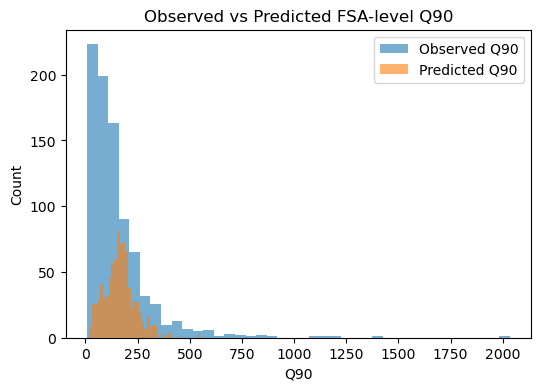

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(fsa_cv_df["observed_q90"], bins=40, alpha=0.6, label="Observed Q90")
plt.hist(fsa_cv_df["predicted_q90"], bins=40, alpha=0.6, label="Predicted Q90")
plt.legend()
plt.xlabel("Q90")
plt.ylabel("Count")
plt.title("Observed vs Predicted FSA-level Q90")
plt.show()

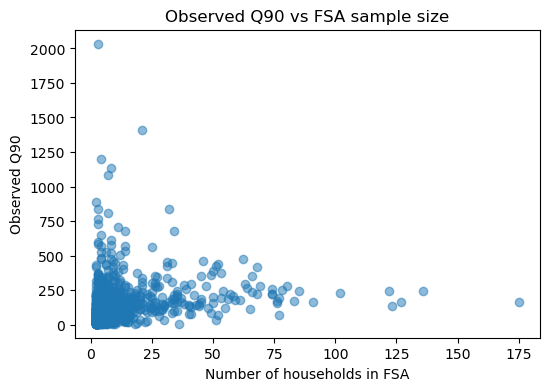

In [145]:
plt.figure(figsize=(6,4))
plt.scatter(fsa_cv_df["n_households"], fsa_cv_df["observed_q90"], alpha=0.5)
plt.xlabel("Number of households in FSA")
plt.ylabel("Observed Q90")
plt.title("Observed Q90 vs FSA sample size")
plt.show()

In [146]:
fsa_cv_df_large = fsa_cv_df[fsa_cv_df["n_households"] >= 20]
fsa_cv_df_large[["predicted_q90", "observed_q90"]].describe()

,predicted_q90,observed_q90
count,139.000000,139.000000
mean,209.372129,220.441007
std,61.692779,160.531512
min,65.260339,7.500000
25%,169.914366,135.350000
50%,205.309548,187.000000
75%,246.053818,271.350000
max,410.584416,1412.000000


In [147]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, balanced_accuracy_score

fsa_cv_df["pred_high_risk"] = (fsa_cv_df["predicted_q90"] > 200).astype(int)
fsa_cv_df["true_high_risk_q90"] = (fsa_cv_df["observed_q90"] > 200).astype(int)
fsa_cv_df["true_high_risk_exceed"] = (fsa_cv_df["observed_exceedance_rate"] > 0.1).astype(int)

for truth_col in ["true_high_risk_q90", "true_high_risk_exceed"]:
    y_true = fsa_cv_df[truth_col]
    y_pred = fsa_cv_df["pred_high_risk"]

    print("\n", truth_col)
    print(confusion_matrix(y_true, y_pred))
    print("precision:", precision_score(y_true, y_pred, zero_division=0))
    print("recall:", recall_score(y_true, y_pred, zero_division=0))
    print("f1:", f1_score(y_true, y_pred, zero_division=0))
    print("balanced_accuracy:", balanced_accuracy_score(y_true, y_pred))


 true_high_risk_q90
[[536 120]
 [ 94 104]]
precision: 0.4642857142857143
recall: 0.5252525252525253
f1: 0.4928909952606635
balanced_accuracy: 0.6711628479921163

 true_high_risk_exceed
[[511 117]
 [119 107]]
precision: 0.47767857142857145
recall: 0.47345132743362833
f1: 0.47555555555555556
balanced_accuracy: 0.6435727974747759


The results shows that the model tends to overestimate the low-risk FSAs, and cannot predict the extremely heavy tails. This can be caused by small number of households in many FSAs.

Next attempts:

1. Check different q values

2. Filter out FSAs with small sample size.

In [148]:
### Check model performance at different q values

results = []

for q in [0.75, 0.80, 0.85, 0.90, 0.95]:
    all_fold_predictions = []

    for fold in range(5):
        train_df = load_training_data(cv_fold=fold)
        val_df = load_validation_data(cv_fold=fold)

        X_train, y_train = prepare_X_y(train_df)
        X_val, y_val = prepare_X_y(val_df)

        X_train_imp, X_val_imp = impute_train_val(X_train, X_val)

        model_gbqr = GradientBoostingRegressor(
            loss="quantile",
            alpha=q,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=12345
        )

        model_gbqr.fit(X_train_imp, y_train)
        pred_log_q = model_gbqr.predict(X_val_imp)

        fold_pred = val_df.copy()
        fold_pred["pred_q"] = np.exp(pred_log_q)
        fold_pred["fold"] = fold
        all_fold_predictions.append(fold_pred)

    cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)

    fsa_pred = (
        cv_pred_df.groupby(["FSA", "fold"])["pred_q"]
        .first()
        .reset_index(name="predicted_q")
    )

    fsa_obs_q = (
        cv_pred_df.groupby(["FSA", "fold"])["concentration"]
        .quantile(q)
        .reset_index(name="observed_q")
    )

    fsa_obs_exceed = (
        cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > 200).astype(int))
        .groupby(["FSA", "fold"])["y_binary"]
        .mean()
        .reset_index(name="observed_exceedance_rate")
    )

    fsa_n = (
        cv_pred_df.groupby(["FSA", "fold"])
        .size()
        .reset_index(name="n_households")
    )

    fsa_df = (
        fsa_pred
        .merge(fsa_obs_q, on=["FSA", "fold"])
        .merge(fsa_obs_exceed, on=["FSA", "fold"])
        .merge(fsa_n, on=["FSA", "fold"])
    )

    # prediction rule
    y_pred = (fsa_df["predicted_q"] > 200).astype(int)

    # truth rule: exceedance rate > 0.1
    y_true = (fsa_df["observed_exceedance_rate"] > 0.1).astype(int)

    results.append({
        "q": q,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_pred_high_risk": int(y_pred.sum()),
        "n_true_high_risk": int(y_true.sum())
    })

results_df = pd.DataFrame(results).sort_values("q")
results_df

,q,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk
0,0.75,1.000000,0.022124,0.043290,0.511062,5,226
1,0.80,0.689655,0.088496,0.156863,0.537082,29,226
2,0.85,0.564356,0.252212,0.348624,0.591074,101,226
3,0.90,0.477679,0.473451,0.475556,0.643573,224,226
4,0.95,0.343580,0.840708,0.487805,0.631341,553,226


Compared with q=0.90, q=0.95 substantially increases recall and gives the best F1 and balanced accuracy, but it also greatly overpredicts the number of high-risk FSAs. It is more suitable in predicting high-risk areas, but with many False Positives.

q=0.90 provides a more balanced trade-off between precision and recall and yields a predicted number of high-risk areas close to the observed count.

#### Test GBQR parameters
Next, test GBQR parameteres with q = 0.90 with different GBQR parameters:

In [149]:
### Check model performance at different max_depth values
### max_depth: The maximum depth of each individual decision tree, which controls how complex each tree can be.
q = 0.90
results = []

for max_dep in [2,3,4,5]:
    all_fold_predictions = []

    for fold in range(5):
        train_df = load_training_data(cv_fold=fold)
        val_df = load_validation_data(cv_fold=fold)

        X_train, y_train = prepare_X_y(train_df)
        X_val, y_val = prepare_X_y(val_df)

        X_train_imp, X_val_imp = impute_train_val(X_train, X_val)

        model_gbqr = GradientBoostingRegressor(
            loss="quantile",
            alpha=q,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=max_dep,
            random_state=12345
        )

        model_gbqr.fit(X_train_imp, y_train)
        pred_log_q = model_gbqr.predict(X_val_imp)

        fold_pred = val_df.copy()
        fold_pred["pred_q"] = np.exp(pred_log_q)
        fold_pred["fold"] = fold
        all_fold_predictions.append(fold_pred)

    cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)

    fsa_pred = (
        cv_pred_df.groupby(["FSA", "fold"])["pred_q"]
        .first()
        .reset_index(name="predicted_q")
    )

    fsa_obs_q = (
        cv_pred_df.groupby(["FSA", "fold"])["concentration"]
        .quantile(q)
        .reset_index(name="observed_q")
    )

    fsa_obs_exceed = (
        cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > 200).astype(int))
        .groupby(["FSA", "fold"])["y_binary"]
        .mean()
        .reset_index(name="observed_exceedance_rate")
    )

    fsa_n = (
        cv_pred_df.groupby(["FSA", "fold"])
        .size()
        .reset_index(name="n_households")
    )

    fsa_df = (
        fsa_pred
        .merge(fsa_obs_q, on=["FSA", "fold"])
        .merge(fsa_obs_exceed, on=["FSA", "fold"])
        .merge(fsa_n, on=["FSA", "fold"])
    )

    # prediction rule
    y_pred = (fsa_df["predicted_q"] > 200).astype(int)

    # truth rule: exceedance rate > 0.1
    y_true = (fsa_df["observed_exceedance_rate"] > 0.1).astype(int)

    results.append({
        "max_depth": max_dep,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_pred_high_risk": int(y_pred.sum()),
        "n_true_high_risk": int(y_true.sum())
    })

results_df = pd.DataFrame(results).sort_values("max_depth")
results_df

,max_depth,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk
0,2,0.446281,0.477876,0.461538,0.632250,242,226
1,3,0.477679,0.473451,0.475556,0.643573,224,226
2,4,0.456221,0.438053,0.446953,0.625078,217,226
3,5,0.473171,0.429204,0.450116,0.628615,205,226


max_depth = 2 performs better

In [150]:
### Check model performance at different min_samples_leaf values
##### min_samples_leaf: The minimum number of samples required to be in a leaf node, 
##### which helps prevent the tree from becoming too specific.
q = 0.90
results = []

for min_leaf in [1,2,3,4,5,10]:
    all_fold_predictions = []

    for fold in range(5):
        train_df = load_training_data(cv_fold=fold)
        val_df = load_validation_data(cv_fold=fold)

        X_train, y_train = prepare_X_y(train_df)
        X_val, y_val = prepare_X_y(val_df)

        X_train_imp, X_val_imp = impute_train_val(X_train, X_val)

        model_gbqr = GradientBoostingRegressor(
            loss="quantile",
            alpha=q,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=min_leaf,
            random_state=12345
        )

        model_gbqr.fit(X_train_imp, y_train)
        pred_log_q = model_gbqr.predict(X_val_imp)

        fold_pred = val_df.copy()
        fold_pred["pred_q"] = np.exp(pred_log_q)
        fold_pred["fold"] = fold
        all_fold_predictions.append(fold_pred)

    cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)

    fsa_pred = (
        cv_pred_df.groupby(["FSA", "fold"])["pred_q"]
        .first()
        .reset_index(name="predicted_q")
    )

    fsa_obs_q = (
        cv_pred_df.groupby(["FSA", "fold"])["concentration"]
        .quantile(q)
        .reset_index(name="observed_q")
    )

    fsa_obs_exceed = (
        cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > 200).astype(int))
        .groupby(["FSA", "fold"])["y_binary"]
        .mean()
        .reset_index(name="observed_exceedance_rate")
    )

    fsa_n = (
        cv_pred_df.groupby(["FSA", "fold"])
        .size()
        .reset_index(name="n_households")
    )

    fsa_df = (
        fsa_pred
        .merge(fsa_obs_q, on=["FSA", "fold"])
        .merge(fsa_obs_exceed, on=["FSA", "fold"])
        .merge(fsa_n, on=["FSA", "fold"])
    )

    # prediction rule
    y_pred = (fsa_df["predicted_q"] > 200).astype(int)

    # truth rule: exceedance rate > 0.1
    y_true = (fsa_df["observed_exceedance_rate"] > 0.1).astype(int)

    results.append({
        "min_samples_leaf": min_leaf,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_pred_high_risk": int(y_pred.sum()),
        "n_true_high_risk": int(y_true.sum())
    })

results_df = pd.DataFrame(results).sort_values("min_samples_leaf")
results_df

,min_samples_leaf,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk
0,1,0.446281,0.477876,0.461538,0.632250,242,226
1,2,0.446281,0.477876,0.461538,0.632250,242,226
2,3,0.438017,0.469027,0.452991,0.626233,242,226
3,4,0.448560,0.482301,0.464819,0.634463,243,226
4,5,0.451883,0.477876,0.464516,0.634639,239,226
5,10,0.449799,0.495575,0.471579,0.638711,249,226


min_samples_leaf = 2 performs better

In [151]:
### Check model performance at different learning_rate values
### learning_rate: A scaling factor that controls how much each new tree contributes to the final prediction.
q = 0.90
results = []

for r_learning in [0.01, 0.02, 0.03, 0.05, 0.1]: 
    all_fold_predictions = []

    for fold in range(5):
        train_df = load_training_data(cv_fold=fold)
        val_df = load_validation_data(cv_fold=fold)

        X_train, y_train = prepare_X_y(train_df)
        X_val, y_val = prepare_X_y(val_df)

        X_train_imp, X_val_imp = impute_train_val(X_train, X_val)

        model_gbqr = GradientBoostingRegressor(
            loss="quantile",
            alpha=q,
            n_estimators=200,
            learning_rate=r_learning,
            max_depth=2,
            min_samples_leaf=2,
            random_state=12345
        )

        model_gbqr.fit(X_train_imp, y_train)
        pred_log_q = model_gbqr.predict(X_val_imp)

        fold_pred = val_df.copy()
        fold_pred["pred_q"] = np.exp(pred_log_q)
        fold_pred["fold"] = fold
        all_fold_predictions.append(fold_pred)

    cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)

    fsa_pred = (
        cv_pred_df.groupby(["FSA", "fold"])["pred_q"]
        .first()
        .reset_index(name="predicted_q")
    )

    fsa_obs_q = (
        cv_pred_df.groupby(["FSA", "fold"])["concentration"]
        .quantile(q)
        .reset_index(name="observed_q")
    )

    fsa_obs_exceed = (
        cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > 200).astype(int))
        .groupby(["FSA", "fold"])["y_binary"]
        .mean()
        .reset_index(name="observed_exceedance_rate")
    )

    fsa_n = (
        cv_pred_df.groupby(["FSA", "fold"])
        .size()
        .reset_index(name="n_households")
    )

    fsa_df = (
        fsa_pred
        .merge(fsa_obs_q, on=["FSA", "fold"])
        .merge(fsa_obs_exceed, on=["FSA", "fold"])
        .merge(fsa_n, on=["FSA", "fold"])
    )

    # prediction rule
    y_pred = (fsa_df["predicted_q"] > 200).astype(int)

    # truth rule: exceedance rate > 0.1
    y_true = (fsa_df["observed_exceedance_rate"] > 0.1).astype(int)

    results.append({
        "learning_rate": r_learning,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_pred_high_risk": int(y_pred.sum()),
        "n_true_high_risk": int(y_true.sum())
    })

results_df = pd.DataFrame(results).sort_values("learning_rate")
results_df

,learning_rate,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk
0,0.01,0.426667,0.566372,0.486692,0.646243,300,226
1,0.02,0.439689,0.500000,0.467909,0.635350,257,226
2,0.03,0.447154,0.486726,0.466102,0.635083,246,226
3,0.05,0.446281,0.477876,0.461538,0.632250,242,226
4,0.10,0.451220,0.491150,0.470339,0.638091,246,226


learning_rate = 0.01 performs better in terms of balancing precision and recall

In [152]:
### Check model performance at different subsample values
q = 0.90
results = []

for subsamp in [0.7, 0.8, 0.85, 0.9, 1.0]:  # subsample = 1 means each tree uses all the training samples
    all_fold_predictions = []

    for fold in range(5):
        train_df = load_training_data(cv_fold=fold)
        val_df = load_validation_data(cv_fold=fold)

        X_train, y_train = prepare_X_y(train_df)
        X_val, y_val = prepare_X_y(val_df)

        X_train_imp, X_val_imp = impute_train_val(X_train, X_val)

        model_gbqr = GradientBoostingRegressor(
            loss="quantile",
            alpha=q,
            n_estimators=200,
            learning_rate=0.01,
            max_depth=2,
            min_samples_leaf=4,
            subsample=subsamp,
            random_state=12345
        )

        model_gbqr.fit(X_train_imp, y_train)
        pred_log_q = model_gbqr.predict(X_val_imp)

        fold_pred = val_df.copy()
        fold_pred["pred_q"] = np.exp(pred_log_q)
        fold_pred["fold"] = fold
        all_fold_predictions.append(fold_pred)

    cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)

    fsa_pred = (
        cv_pred_df.groupby(["FSA", "fold"])["pred_q"]
        .first()
        .reset_index(name="predicted_q")
    )

    fsa_obs_q = (
        cv_pred_df.groupby(["FSA", "fold"])["concentration"]
        .quantile(q)
        .reset_index(name="observed_q")
    )

    fsa_obs_exceed = (
        cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > 200).astype(int))
        .groupby(["FSA", "fold"])["y_binary"]
        .mean()
        .reset_index(name="observed_exceedance_rate")
    )

    fsa_n = (
        cv_pred_df.groupby(["FSA", "fold"])
        .size()
        .reset_index(name="n_households")
    )

    fsa_df = (
        fsa_pred
        .merge(fsa_obs_q, on=["FSA", "fold"])
        .merge(fsa_obs_exceed, on=["FSA", "fold"])
        .merge(fsa_n, on=["FSA", "fold"])
    )

    # prediction rule
    y_pred = (fsa_df["predicted_q"] > 200).astype(int)

    # truth rule: exceedance rate > 0.1
    y_true = (fsa_df["observed_exceedance_rate"] > 0.1).astype(int)

    results.append({
        "subsample": subsamp,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_pred_high_risk": int(y_pred.sum()),
        "n_true_high_risk": int(y_true.sum())
    })

results_df = pd.DataFrame(results).sort_values("subsample")
results_df

,subsample,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk
0,0.70,0.418118,0.530973,0.467836,0.632525,287,226
1,0.80,0.417508,0.548673,0.474187,0.636597,297,226
2,0.85,0.423208,0.548673,0.477842,0.639782,293,226
3,0.90,0.430976,0.566372,0.489484,0.648632,297,226
4,1.00,0.426667,0.566372,0.486692,0.646243,300,226


subsample = 0.90 performs better

In [153]:
### Check model performance at different n_estimators values
### n_estimators: The number of boosting stages, or equivalently the number of trees added sequentially to improve the prediction.
q = 0.90
results = []

for n_est in [5, 10, 15, 20, 30, 50, 60, 80, 100, 200, 300]:  # n_estimator
    all_fold_predictions = []

    for fold in range(5):
        train_df = load_training_data(cv_fold=fold)
        val_df = load_validation_data(cv_fold=fold)

        X_train, y_train = prepare_X_y(train_df)
        X_val, y_val = prepare_X_y(val_df)

        X_train_imp, X_val_imp = impute_train_val(X_train, X_val)

        model_gbqr = GradientBoostingRegressor(
            loss="quantile",
            alpha=q,
            n_estimators=n_est,
            learning_rate=r_learning,
            max_depth=2,
            min_samples_leaf=4,
            subsample=0.90,
            random_state=12345
        )

        model_gbqr.fit(X_train_imp, y_train)
        pred_log_q = model_gbqr.predict(X_val_imp)

        fold_pred = val_df.copy()
        fold_pred["pred_q"] = np.exp(pred_log_q)
        fold_pred["fold"] = fold
        all_fold_predictions.append(fold_pred)

    cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)

    fsa_pred = (
        cv_pred_df.groupby(["FSA", "fold"])["pred_q"]
        .first()
        .reset_index(name="predicted_q")
    )

    fsa_obs_q = (
        cv_pred_df.groupby(["FSA", "fold"])["concentration"]
        .quantile(q)
        .reset_index(name="observed_q")
    )

    fsa_obs_exceed = (
        cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > 200).astype(int))
        .groupby(["FSA", "fold"])["y_binary"]
        .mean()
        .reset_index(name="observed_exceedance_rate")
    )

    fsa_n = (
        cv_pred_df.groupby(["FSA", "fold"])
        .size()
        .reset_index(name="n_households")
    )

    fsa_df = (
        fsa_pred
        .merge(fsa_obs_q, on=["FSA", "fold"])
        .merge(fsa_obs_exceed, on=["FSA", "fold"])
        .merge(fsa_n, on=["FSA", "fold"])
    )

    # prediction rule
    y_pred = (fsa_df["predicted_q"] > 200).astype(int)

    # truth rule: exceedance rate > 0.1
    y_true = (fsa_df["observed_exceedance_rate"] > 0.1).astype(int)

    results.append({
        "n_estimators": n_est,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_pred_high_risk": int(y_pred.sum()),
        "n_true_high_risk": int(y_true.sum())
    })

results_df = pd.DataFrame(results).sort_values("n_estimators")
results_df

,n_estimators,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk
0,5,0.371274,0.606195,0.460504,0.618384,369,226
1,10,0.386707,0.566372,0.459605,0.621562,331,226
2,15,0.405063,0.566372,0.472325,0.633504,316,226
3,20,0.429066,0.548673,0.481553,0.642967,289,226
4,30,0.426966,0.504425,0.462475,0.630397,267,226
5,50,0.444444,0.495575,0.468619,0.636323,252,226
6,60,0.440816,0.477876,0.458599,0.629862,245,226
7,80,0.437247,0.477876,0.456660,0.628269,247,226
8,100,0.446721,0.482301,0.463830,0.633666,244,226
9,200,0.454148,0.460177,0.457143,0.630566,229,226


n_estimators = 20 performs better

Compared with Dummy Regressor:

In [154]:
results = []

for q in [0.90, 0.95]:
    all_fold_predictions = []

    for fold in range(5):
        train_df = load_training_data(cv_fold=fold)
        val_df = load_validation_data(cv_fold=fold)

        X_train, y_train = prepare_X_y(train_df)
        X_val, y_val = prepare_X_y(val_df)

        model_dummy = DummyRegressor(strategy="quantile", quantile=q)
        model_dummy.fit(X_train, y_train)

        pred_log_q = model_dummy.predict(X_val)

        fold_pred = val_df.copy()
        fold_pred["pred_q"] = np.exp(pred_log_q)
        fold_pred["fold"] = fold
        all_fold_predictions.append(fold_pred)

    cv_pred_df = pd.concat(all_fold_predictions, ignore_index=True)

    fsa_pred = (
        cv_pred_df.groupby(["FSA", "fold"])["pred_q"]
        .first()
        .reset_index(name="predicted_q")
    )

    fsa_obs_exceed = (
        cv_pred_df.assign(y_binary=(cv_pred_df["concentration"] > 200).astype(int))
        .groupby(["FSA", "fold"])["y_binary"]
        .mean()
        .reset_index(name="observed_exceedance_rate")
    )

    fsa_df = (
        fsa_pred
        .merge(fsa_obs_exceed, on=["FSA", "fold"])
    )

    # prediction rule
    y_pred = (fsa_df["predicted_q"] > 200).astype(int)

    # truth rule
    y_true = (fsa_df["observed_exceedance_rate"] > 0.1).astype(int)

    results.append({
        "q": q,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_pred_high_risk": int(y_pred.sum()),
        "n_true_high_risk": int(y_true.sum()),
        "predicted_q_example": float(fsa_df["predicted_q"].iloc[0])
    })

dummy_classification_results = pd.DataFrame(results).sort_values("q").reset_index(drop=True)
dummy_classification_results

,q,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk,predicted_q_example
0,0.90,0.264637,1.0,0.418519,0.5,854,226,202.0
1,0.95,0.264637,1.0,0.418519,0.5,854,226,290.0


The current model performance (q=0.90):

In [155]:
results_df.loc[results_df["n_estimators"] == 20, 
               ["precision", "recall", "f1", "balanced_accuracy", "n_pred_high_risk", "n_true_high_risk"]].reset_index(drop=True)

,precision,recall,f1,balanced_accuracy,n_pred_high_risk,n_true_high_risk
0,0.429066,0.548673,0.481553,0.642967,289,226


**Summary:**

**1. The dummy model predicts Q90 is 202 Bq/m3, which is above 200. So all FSAs are labeled as high risk, which leads to recall=1 but but very poor precision and balanced accuracy.**

**2. Compared with the dummy model, the GBQR model has a substantial improvement in precision (0.265 -> 0.482), F1 (0.419 -> 0.482), balanced accuracy (0.5 -> 0.643), while reducing but the number of predicted high-risk FSAs to a value close to the observed count.**